In [12]:
import math 
import numpy as np 
import matplotlib.pyplot as plt

In [18]:
# -----------------------------
# Physical properties
# -----------------------------
mu = 1e-3
rho = 1000
g = 9.81

# intrinsic permeability (typical limestone order-of-magnitude)
# set to 1e-12 m^2 (adjust if you have measured values)
k_intrinsic = 1e-4

# hydraulic conductivity [m/s]
K = k_intrinsic * rho * g / mu
print('Hydraulic conductivity K =', K, 'm/s')

# -----------------------------
# Falling head solver
# -----------------------------
def falling_head(
    t_end,
    dt,
    h0,
    K,
    r_sample,
    r_pipe,
    L
):

    t = np.arange(0, t_end + dt, dt)

    h = np.zeros_like(t)
    Q = np.zeros_like(t)
    v = np.zeros_like(t)

    h[0] = h0

    A_sample = math.pi * r_sample**2
    A_pipe = math.pi * r_pipe**2

    for i in range(1, len(t)):

        # Darcy flow
        Q[i-1] = K * A_sample * h[i-1] / L

        # Darcy velocity
        v[i-1] = Q[i-1] / A_sample

        # head decay
        dhdt = -Q[i-1] / A_pipe

        h[i] = h[i-1] + dhdt * dt

        if h[i] < 0:
            h[i] = 0

    return t, h, Q, v

Hydraulic conductivity K = 981.0000000000001 m/s


In [19]:
# Diagnostic: check magnitudes that control dh/dt
r_pipe_test = 0.004  # 4 mm
r_sample_test = 0.015  # 15 mm sample radius
L_test = 0.10
dt_test = 1.0

A_sample_test = math.pi * r_sample_test**2
A_pipe_test = math.pi * r_pipe_test**2

q0 = K * A_sample_test * (0.2 / L_test)  # use h0=0.2 m for estimate
dhdt0 = - q0 / A_pipe_test

print('K =', K)
print('A_sample (m^2) =', A_sample_test)
print('A_pipe (m^2) =', A_pipe_test)
print('initial q_out (m^3/s) =', q0)
print('initial dh/dt (m/s) =', dhdt0)
print('Δh per step (m) =', dhdt0 * dt_test)

K = 981.0000000000001
A_sample (m^2) = 0.0007068583470577034
A_pipe (m^2) = 5.0265482457436686e-05
initial q_out (m^3/s) = 1.3868560769272142
initial dh/dt (m/s) = -27590.625000000004
Δh per step (m) = -27590.625000000004


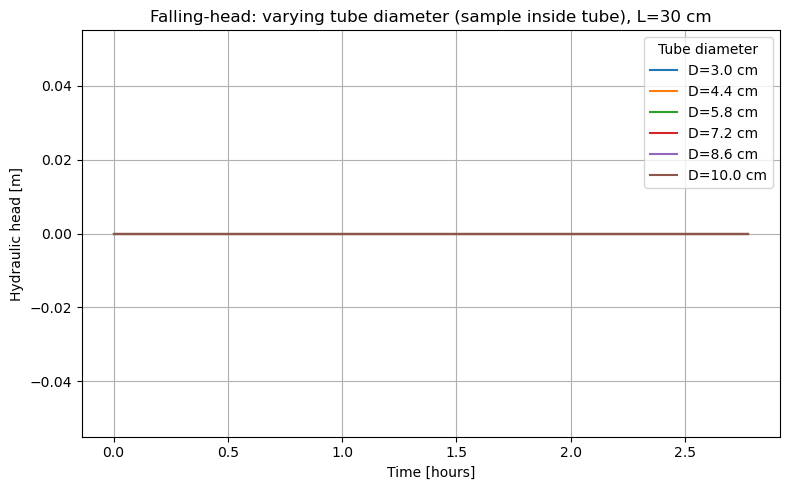

In [20]:
plt.figure(figsize=(8,5))

# Tube diameters 3--10 cm (user request) -> radii in meters
tube_diams = np.linspace(0.03, 0.10, 6)
tube_radii = tube_diams / 2.0

# Sample heights (lengths) 20--40 cm
L_values = np.linspace(0.20, 0.40, 5)

# Example 1: for a fixed sample height, vary tube diameter (sample sits inside tube, same radius)
L_fixed = 0.30  # 30 cm sample height
h0_fixed = L_fixed  # fill water to top of sample initially

for r_tube in tube_radii:
    t, h, Q, v = falling_head(
        t_end=10000,
        dt=10,
        h0=h0_fixed,
        K=K,
        r_sample=r_tube,  # sample same radius as tube
        r_pipe=r_tube,
        L=L_fixed,
    )
    plt.plot(t/3600, h, label=f'D={r_tube*2*100:.1f} cm')

plt.xlabel('Time [hours]')
plt.ylabel('Hydraulic head [m]')
plt.title('Falling-head: varying tube diameter (sample inside tube), L=30 cm')
plt.legend(title='Tube diameter')
plt.grid()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

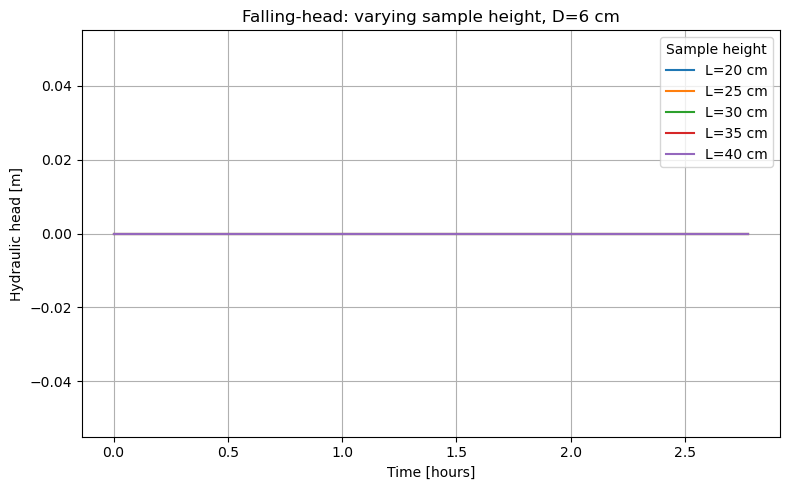

In [21]:
plt.figure(figsize=(8,5))

# Example 2: for a fixed tube diameter, vary sample height L between 20 and 40 cm
plt.figure(figsize=(8,5))
tube_diameter_fixed = 0.06  # 6 cm tube
r_tube_fixed = tube_diameter_fixed / 2.0

for L in L_values:
    h0 = L  # fill to top of sample
    t, h, Q, v = falling_head(
        t_end=10000,
        dt=10,
        h0=h0,
        K=K,
        r_sample=r_tube_fixed,
        r_pipe=r_tube_fixed,
        L=L,
    )
    plt.plot(t/3600, h, label=f'L={L*100:.0f} cm')

plt.xlabel('Time [hours]')
plt.ylabel('Hydraulic head [m]')
plt.title(f'Falling-head: varying sample height, D={tube_diameter_fixed*100:.0f} cm')
plt.legend(title='Sample height')
plt.grid()
plt.tight_layout()
plt.show()

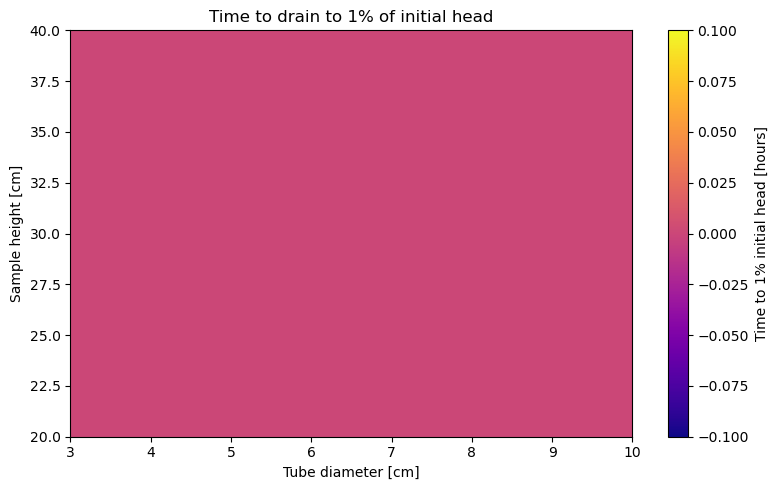

In [22]:
# Heatmap: time to drain to 1% of initial head across diameters and sample heights
tube_diams = np.linspace(0.03, 0.10, 12)
tube_radii = tube_diams / 2.0
L_values = np.linspace(0.20, 0.40, 9)

t_end = 20000
dt = 10
fraction = 0.01

time_to_fraction = np.full((len(L_values), len(tube_radii)), np.nan)

for i, L in enumerate(L_values):
    for j, r in enumerate(tube_radii):
        h0 = L
        t, h, Q, v = falling_head(t_end=t_end, dt=dt, h0=h0, K=K, r_sample=r, r_pipe=r, L=L)
        target = h0 * fraction
        idx = np.where(h <= target)[0]
        if idx.size > 0:
            time_to_fraction[i, j] = t[idx[0]] / 3600.0  # hours
        else:
            time_to_fraction[i, j] = np.nan

plt.figure(figsize=(8,5))
im = plt.imshow(time_to_fraction, origin='lower', aspect='auto',
                extent=[tube_diams[0]*100, tube_diams[-1]*100, L_values[0]*100, L_values[-1]*100], cmap='plasma')
plt.colorbar(im, label='Time to 1% initial head [hours]')
plt.xlabel('Tube diameter [cm]')
plt.ylabel('Sample height [cm]')
plt.title('Time to drain to 1% of initial head')
plt.tight_layout()
plt.show()